In [1]:
#- Cotizaciones
#- Ventas
#- Paquetes más solicitados
#- Conversión
#- Análisis por sucursal
#- Análisis por mes

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("D:/Python_Data_Science_Machine Learning/Código_Python_DS/portafolio_pandas_datasets/analisis-cotizaciones-fiestas-pandas/data/cotizaciones_fiestas.csv")
df.head()

,id_cotizacion,fecha,sucursal,paquete,num_invitados,monto_estimado,estatus,medio_contacto
0,1,2024-01-10,Ecatepec,Paquete Básico,20,4500,Vendida,Web
1,2,2024-01-15,Coacalco,Paquete Premium,35,8500,Cotizada,WhatsApp
2,3,2024-02-03,Satélite,Paquete Plus,30,6500,Vendida,Web
3,4,2024-02-14,Ecatepec,Paquete Premium,40,9200,Vendida,Sucursal
4,5,2024-02-20,Naucalpan,Paquete Básico,18,4200,Cancelada,WhatsApp


In [7]:
df["fecha"] = pd.to_datetime(df["fecha"])
fecha = df["fecha"]
print(fecha)

0    2024-01-10
1    2024-01-15
2    2024-02-03
3    2024-02-14
4    2024-02-20
5    2024-03-05
6    2024-03-12
7    2024-03-22
8    2024-04-02
9    2024-04-18
10   2024-05-04
11   2024-05-19
12   2024-06-01
13   2024-06-09
14   2024-06-16
Name: fecha, dtype: datetime64[ns]


In [8]:
df["mes"] = df["fecha"].dt.to_period("M")
mes = df['mes']
print(mes)

0     2024-01
1     2024-01
2     2024-02
3     2024-02
4     2024-02
5     2024-03
6     2024-03
7     2024-03
8     2024-04
9     2024-04
10    2024-05
11    2024-05
12    2024-06
13    2024-06
14    2024-06
Name: mes, dtype: period[M]


In [9]:
paquetes_mas_solicitados = df["paquete"].value_counts()
paquetes_mas_solicitados

paquete
Paquete Básico     5
Paquete Premium    5
Paquete Plus       5
Name: count, dtype: int64

In [10]:
ventas = df[df["estatus"] == "Vendida"]
ventas.head()

,id_cotizacion,fecha,sucursal,paquete,num_invitados,monto_estimado,estatus,medio_contacto,mes
0,1,2024-01-10,Ecatepec,Paquete Básico,20,4500,Vendida,Web,2024-01
2,3,2024-02-03,Satélite,Paquete Plus,30,6500,Vendida,Web,2024-02
3,4,2024-02-14,Ecatepec,Paquete Premium,40,9200,Vendida,Sucursal,2024-02
6,7,2024-03-12,Satélite,Paquete Premium,45,9800,Vendida,Instagram,2024-03
7,8,2024-03-22,Ecatepec,Paquete Básico,22,4800,Vendida,Web,2024-03


In [11]:
monto_total_vendido = ventas["monto_estimado"].sum()
monto_total_vendido

np.int64(65400)

In [12]:
ventas_por_sucursal = ventas.groupby("sucursal")["monto_estimado"].sum()
ventas_por_sucursal

sucursal
Coacalco      8900
Ecatepec     18500
Naucalpan     9500
Satélite     28500
Name: monto_estimado, dtype: int64

In [13]:
conversion = len(ventas) / len(df) * 100
conversion

60.0

In [14]:
cotizaciones_por_mes = df.groupby("mes")["id_cotizacion"].count()
cotizaciones_por_mes

mes
2024-01    2
2024-02    3
2024-03    3
2024-04    2
2024-05    2
2024-06    3
Freq: M, Name: id_cotizacion, dtype: int64

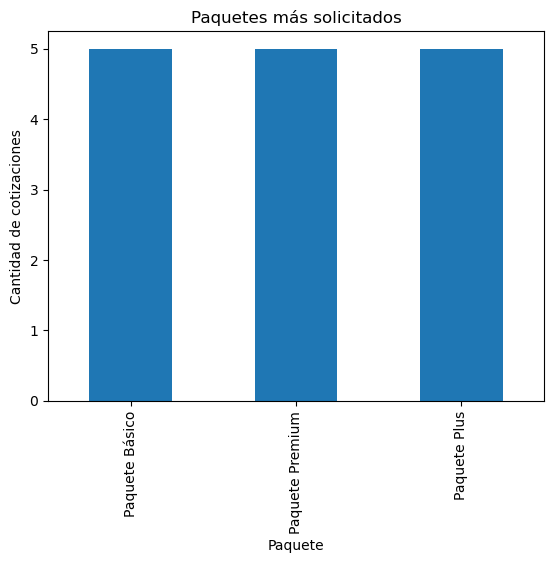

In [15]:
paquetes_mas_solicitados.plot(kind="bar", title="Paquetes más solicitados")
plt.xlabel("Paquete")
plt.ylabel("Cantidad de cotizaciones")
plt.show()

In [16]:
## Conclusiones

#- Se identificaron los paquetes de fiestas más solicitados.
#- Se calculó la tasa de conversión de cotizaciones a ventas.
#- Se analizaron ventas estimadas por sucursal.
#- Se observó el comportamiento mensual de las cotizaciones.
#- El análisis permite detectar oportunidades comerciales y mejorar estrategias de seguimiento.